In [1]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import scanpy as sc
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from model.dataset import BagsDataset, custom_collate_fn
from model.model import MIL, EarlyStopping

In [2]:

def load_all_genes(reference_gene_file):
    all_genes = pd.read_csv(reference_gene_file)
    return all_genes['Gene'].values.tolist()


Define your interested geneset, in this study we use all human/mouse genes as our reference geneset


In [3]:
#define your interested geneset, in this study we use all human/mouse genes as our reference geneset
all_genes = pd.read_csv('data/human_filtered.csv')
all_genes

,Gene
0,C1orf141
1,PKP1
2,HIVEP3
3,GLMN
4,SLC44A5
...,...
23177,EPCAM
23178,CEACAM21
23179,CEACAM6
23180,KRT8


In [4]:
all_genes = all_genes['Gene'].values.tolist()

Load the data

In [8]:
# Load dataset and create DataLoader(details data structure in data preparation section)
adata = sc.read_h5ad('data/example_data.h5ad')
dataset = BagsDataset(
    adata,
    immune_cell='tcell',
    radius=50,
    max_instances=500,
    n_genes=500,
    resolution='high',
    k=2,  # Ensure 'k' matches the number of bags per batch
)

Immune cell: T
[1 0 2]
Tumor cells shape after filtering: (27567, 18085)
Selecting top 500 genes based on mean expression


/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessed data: (52518, 559)


Creating Bags with radius 50: 100%|█████████████████████████| 52518/52518 [00:08<00:00, 5877.20it/s]

Total batches created: 153


If you want run the model for multiple data

In [6]:
adatas = pd.read_csv('data/all_data/tcell_cosmx.csv')
adatas #make sure you have same data structure as in sample.csv

,adata,radius,resolution
0,/work/DPDS/s439765/data4spacer/spatial_transcr...,100,high
1,/work/DPDS/s439765/data4spacer/spatial_transcr...,100,high


In [7]:
dataset = BagsDataset(
    'data/all_data/tcell_cosmx.csv',
    immune_cell='tcell',
    max_instances=500,
    n_genes=500,
    k=2,  # Ensure 'k' matches the number of bags per batch
)

Immune cell: T
Reading adata from /work/DPDS/s439765/data4spacer/spatial_transcriptomics/linghua_cosmx/GAME3D6/d6_sample1_Tcell.h5ad
[1 0 2]
Tumor cells shape after filtering: (30903, 20385)
Selecting top 500 genes based on mean expression


/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Processing: adata=d6_sample1_Tcell.h5ad, radius=100, resolution=high
Reading adata from /work/DPDS/s439765/data4spacer/spatial_transcriptomics/linghua_cosmx/GAME3D6/d6_sample2_Tcell.h5ad
[0 1 2]
Tumor cells shape after filtering: (31353, 20385)
Selecting top 500 genes based on mean expression


/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/work/OSPH/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Processing: adata=d6_sample2_Tcell.h5ad, radius=100, resolution=high


Creating Bags with radius 100:  38%|█████████               | 21510/56900 [00:06<00:10, 3269.38it/s]


KeyboardInterrupt: 

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"Using device: {device} ({torch.cuda.get_device_name(torch.cuda.current_device())})")
else:
    print(f"Using device: {device}")
print("=====================================")

Using device: cuda (Tesla V100-SXM2-32GB)


In [10]:
model = MIL(all_genes).to(device)
criterion = nn.BCELoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.02)
early_stopping = EarlyStopping(patience=5, delta=0.001)

In [11]:
output_dir = 'test'
os.makedirs(output_dir, exist_ok=True)

In [12]:
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)

In [13]:
best_val_loss = float('inf')
best_model_path = os.path.join(output_dir, 'best_model.pth')

# Save spacer scores before training
spacer_scores_before_training = model.immunogenicity.ig.clone().detach().cpu()
spacer_scores_before_training = [score.item() for score in spacer_scores_before_training]

In [14]:
def save_metrics(epoch, train_loss, val_loss, val_auroc, a, b, alpha, beta, output_dir):
    file_path = os.path.join(output_dir, 'training_metrics.csv')
    if not os.path.exists(file_path):
        # Create the CSV file with headers
        with open(file_path, 'w') as f:
            f.write('Epoch,Train Loss,Val Loss,Val AUROC,a,b,alpha,beta\n')
    
    # Append metrics for the current epoch
    with open(file_path, 'a') as f:
        f.write(f'{epoch},{train_loss},{val_loss},{val_auroc},{a},{b},{alpha},{beta}\n')

def save_spacer_scores(epoch, all_genes, spacer_scores_before_training, spacer_scores_after_training, output_dir):
    # Create a DataFrame with IG scores before and after the current epoch
    spacer_score_data = {
        'Gene': all_genes,
        'SPACER Score Before Training': spacer_scores_before_training,
        'SPACER Score After Training': spacer_scores_after_training,
    }
    df = pd.DataFrame(spacer_score_data)
    
    # Calculate the difference and add it as a new column
    df['Difference'] = df['SPACER Score After Training'] - df['SPACER Score Before Training']
    df = df.sort_values(by='Difference', ascending=False)

    # Save to a CSV file for each epoch
    output_path = os.path.join(output_dir, f'spacer_score_changes_epoch_{epoch+1}.csv')
    df.to_csv(output_path, index=False)

Training

In [21]:
num_epochs = 20
selection = 'positive' # Choose 'positive(induce)' or 'negative(repel)' based on your research focus

In [22]:

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
        
    # Lists to store outputs and labels for AUROC calculation
    all_outputs = []
    all_labels = []
        
    with tqdm(train_loader, unit="batch") as tepoch:
        for i, batch_data in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}/{num_epochs}")
            optimizer.zero_grad()

            # Unpack the batch data
            distances_list, gene_expressions_list, labels_list, core_idxs_list, gene_names_list, cell_ids_list = batch_data
                
            # Move data to device and prepare labels
            distances_list = [distances.to(device) for distances in distances_list]
            gene_expressions_list = [gene_exp.to(device) for gene_exp in gene_expressions_list]
            labels = torch.stack(labels_list).float().to(device)
            current_genes_list = gene_names_list  # List of gene names for each bag

            # Forward pass
            outputs = model(distances_list, gene_expressions_list, current_genes_list)
                
            if outputs is None:
                 continue  # Skip this batch if the model returns None
                
            if outputs.shape[0] != labels.shape[0]:
                # Handle mismatch in batch sizes if necessary
                continue
                
            # Compute BCE loss
            if selection == 'negative':
                labels = 1 - labels
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
            running_loss += loss.item()
            tepoch.set_postfix(loss=loss.item())
                
            # Accumulate outputs and labels for AUROC calculation
            all_outputs.extend(outputs.detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
        
    # Compute Training AUROC
    try:
        epoch_auc = roc_auc_score(all_labels, all_outputs)
    except ValueError:
        epoch_auc = float('nan')  # Handle case where AUROC can't be computed
        
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, AUROC: {epoch_auc:.4f}')
        
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_all_outputs = []
    val_all_labels = []
    with torch.no_grad():
        with tqdm(val_loader, unit="batch") as vtepoch:
            for val_batch_data in vtepoch:
                # Unpack validation batch data
                val_distances_list, val_gene_expressions_list, val_labels_list, val_core_idxs_list, val_gene_names_list, val_cell_ids_list = val_batch_data
                    
                # Move data to device and prepare labels
                val_distances_list = [distances.to(device) for distances in val_distances_list]
                val_gene_expressions_list = [gene_exp.to(device) for gene_exp in val_gene_expressions_list]
                val_labels = torch.stack(val_labels_list).float().to(device)
                val_current_genes_list = val_gene_names_list  # List of gene names for each bag
                    
                # Forward pass
                val_outputs = model(val_distances_list, val_gene_expressions_list, val_current_genes_list)
                    
                if val_outputs is None:
                    continue  # Skip this batch if the model returns None
                    
                if val_outputs.shape[0] != val_labels.shape[0]:
                    # Handle mismatch in batch sizes if necessary
                    continue
                    
                # Compute BCE loss
                if selection == 'negative':
                    val_labels = 1 - val_labels
                loss = criterion(val_outputs, val_labels)
                val_loss += loss.item()
                vtepoch.set_postfix(val_loss=loss.item())
                    
                # Accumulate outputs and labels for AUROC calculation
                val_all_outputs.extend(val_outputs.detach().cpu().numpy())
                val_all_labels.extend(val_labels.cpu().numpy())
            
        val_loss /= len(val_loader)
            
            # Compute Validation AUROC
        try:
            val_epoch_auc = roc_auc_score(val_all_labels, val_all_outputs)
        except ValueError:
            val_epoch_auc = float('nan')  # Handle case where AUROC can't be computed
            
        print(f'Validation Loss: {val_loss:.4f}, Validation AUROC: {val_epoch_auc:.4f}')

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved with validation loss {val_loss:.4f}")
            
    torch.save(model.state_dict(), os.path.join(output_dir, f'model_epoch_{epoch+1}.pth'))
        
    a = model.distance.a.clone().detach().cpu().numpy()
    b = model.gene_expression.b.clone().detach().cpu()
    alpha = model.alpha.clone().detach().cpu()
    beta = model.beta.clone().detach().cpu()
    # Save metrics
    save_metrics(epoch+1, train_loss, val_loss, val_epoch_auc,a,b,alpha,beta, output_dir)

    # Save IG scores after each epoch
    spacer_scores_after_training = model.immunogenicity.ig.clone().detach().cpu()
    spacer_scores_after_training = [score.item() for score in spacer_scores_after_training]
    save_spacer_scores(epoch, all_genes, spacer_scores_before_training, spacer_scores_after_training, output_dir)

Epoch 1/20: 100%|██████████| 137/137 [00:03<00:00, 41.84batch/s, loss=0.699]


Epoch [1/20], Loss: 0.6733, AUROC: 0.7446


100%|██████████| 16/16 [00:00<00:00, 42.32batch/s, val_loss=0.698]


Validation Loss: 0.6505, Validation AUROC: 0.7383
Best model saved with validation loss 0.6505


Epoch 2/20: 100%|██████████| 137/137 [00:03<00:00, 42.37batch/s, loss=0.477]


...

Validation Loss: 0.5185, Validation AUROC: 0.7812
Best model saved with validation loss 0.5185


Epoch 20/20: 100%|██████████| 137/137 [00:03<00:00, 41.45batch/s, loss=0.75] 


Epoch [20/20], Loss: 0.5273, AUROC: 0.8109


100%|██████████| 16/16 [00:00<00:00, 52.99batch/s, val_loss=0.325]


Validation Loss: 0.5259, Validation AUROC: 0.7852


## Training Results Visualization

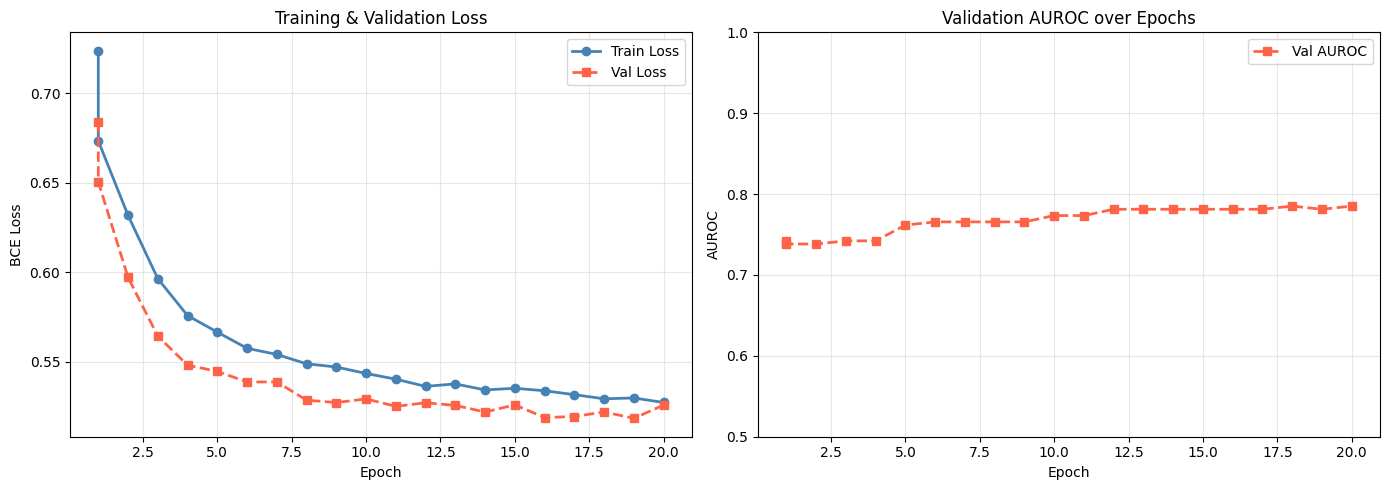

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import os

metrics_path = os.path.join(output_dir, 'training_metrics.csv')
metrics_df = pd.read_csv(metrics_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df['Epoch'], metrics_df['Train Loss'], marker='o',
             label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(metrics_df['Epoch'], metrics_df['Val Loss'], marker='s',
             linestyle='--', label='Val Loss', color='tomato', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df['Epoch'], metrics_df['Val AUROC'], marker='s',
             linestyle='--', label='Val AUROC', color='tomato', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim([0.5, 1.0])
axes[1].set_title('Validation AUROC over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


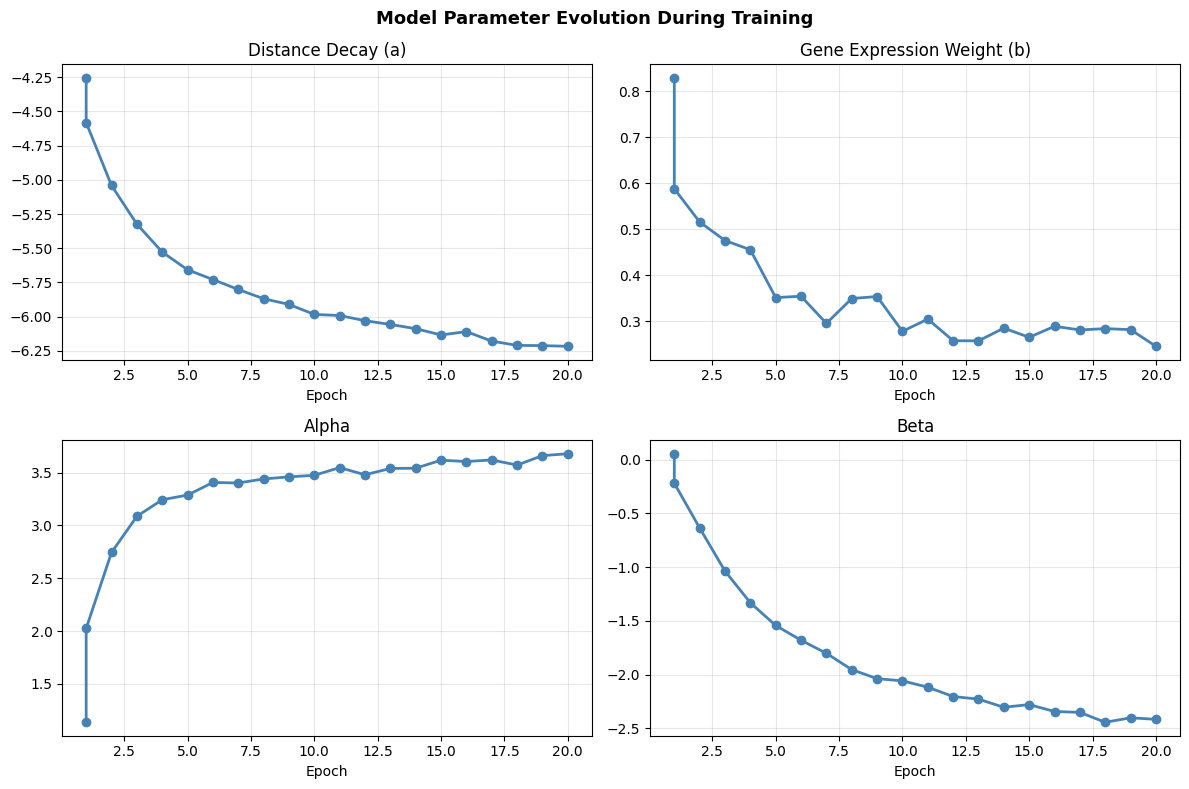

In [24]:
import re
import numpy as np

def parse_scalar(val):
    m = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', str(val).strip())
    return float(m.group()) if m else float('nan')

for col in ['a', 'b', 'alpha', 'beta']:
    metrics_df[col + '_val'] = metrics_df[col].apply(parse_scalar)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
params = [
    ('a_val',     'Distance Decay (a)',           axes[0, 0]),
    ('b_val',     'Gene Expression Weight (b)',    axes[0, 1]),
    ('alpha_val', 'Alpha',                         axes[1, 0]),
    ('beta_val',  'Beta',                          axes[1, 1]),
]
for col, title, ax in params:
    ax.plot(metrics_df['Epoch'], metrics_df[col], marker='o', color='steelblue', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Parameter Evolution During Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'parameter_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()


## SPACER Score Analysis

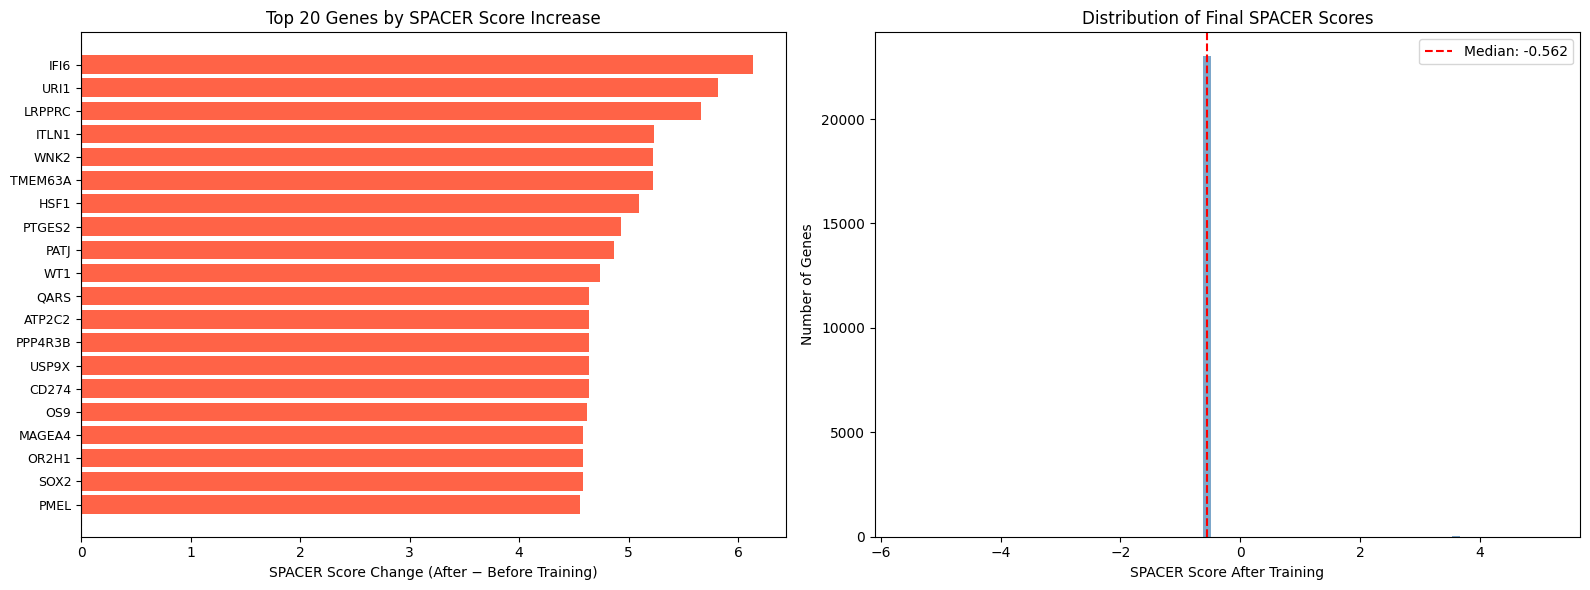

In [25]:
last_epoch_file = os.path.join(output_dir, f'spacer_score_changes_epoch_{num_epochs}.csv')
spacer_df = pd.read_csv(last_epoch_file)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = spacer_df.head(20)
bar_colors = ['tomato' if d > 0 else 'steelblue' for d in top20['Difference']]
axes[0].barh(range(20), top20['Difference'].values[::-1], color=bar_colors[::-1])
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['Gene'].values[::-1], fontsize=9)
axes[0].set_xlabel('SPACER Score Change (After − Before Training)')
axes[0].set_title('Top 20 Genes by SPACER Score Increase')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

final_scores = spacer_df['SPACER Score After Training'].values
axes[1].hist(final_scores, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
axes[1].set_xlabel('SPACER Score After Training')
axes[1].set_ylabel('Number of Genes')
axes[1].set_title('Distribution of Final SPACER Scores')
axes[1].axvline(x=np.median(final_scores), color='red', linestyle='--',
                label=f'Median: {np.median(final_scores):.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'spacer_scores.png'), dpi=150, bbox_inches='tight')
plt.show()
